# White Wine Quality Linear Regression

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

### 1. White Wine Quality Dataset of 4898 Examples

In [ ]:
print("Downloading and loading the Wine Quality dataset...")
# The dataset is provided as a semicolon-separated file
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
df = pd.read_csv(url, sep=';')

print("Dataset loaded successfully. First 5 rows:")
display(df.head())
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully. First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


Dataset shape: (4898, 12)


## 2. Data Preprocessing



In [ ]:
# Separate features (X) and target (y)
X = df.drop('quality', axis=1)
y = df['quality']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preprocessed: features scaled and split into training/testing sets.")

Data preprocessed: features scaled and split into training/testing sets.


## 3. Build and Train a Linear Regression Model



In [ ]:
# A simple neural network with one dense layer (no activation) can perform linear regression.
model = Sequential([
    Dense(1, input_dim=X_train_scaled.shape[1], activation='linear') # Linear activation for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

print("\nModel summary:")
model.summary()

# Train the model
print("\nStarting model training...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,            # Number of training epochs
    batch_size=32,         # Batch size for training
    validation_split=0.2,  # Use 20% of training data for validation
    verbose=0              # Suppress verbose output during training
)
print("Model training complete.")


Model summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12 (48.00 B)

 Trainable params: 12 (48.00 B)

 Non-trainable params: 0 (0.00 B)


Starting model training...
Model training complete.


## 4. Evaluate the Model


In [ ]:
# Evaluate the model on the test set
loss = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nTest Mean Squared Error: {loss:.4f}")

# Make predictions on the test set
y_pred = model.predict(X_test_scaled).flatten()

# Calculate R-squared and RMSE
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R-squared on Test Set: {r2:.4f}")
print(f"Root Mean Squared Error on Test Set: {rmse:.4f}")


Test Mean Squared Error: 0.5867
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
R-squared on Test Set: 0.2425
Root Mean Squared Error on Test Set: 0.7659


## 5. Create Plots



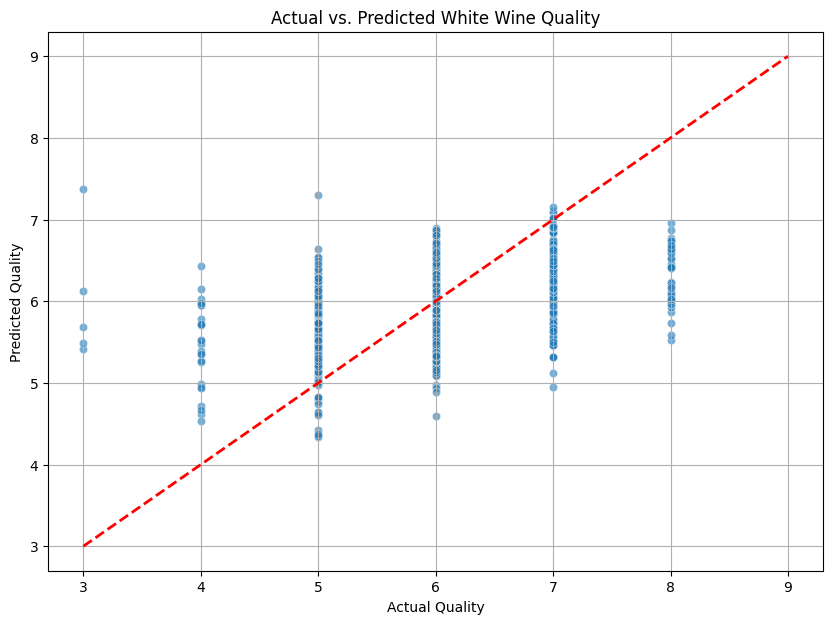

In [ ]:
# Plot 1: Actual vs. Predicted values
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Line for perfect prediction
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.title('Actual vs. Predicted White Wine Quality')
plt.grid(True)
plt.show()

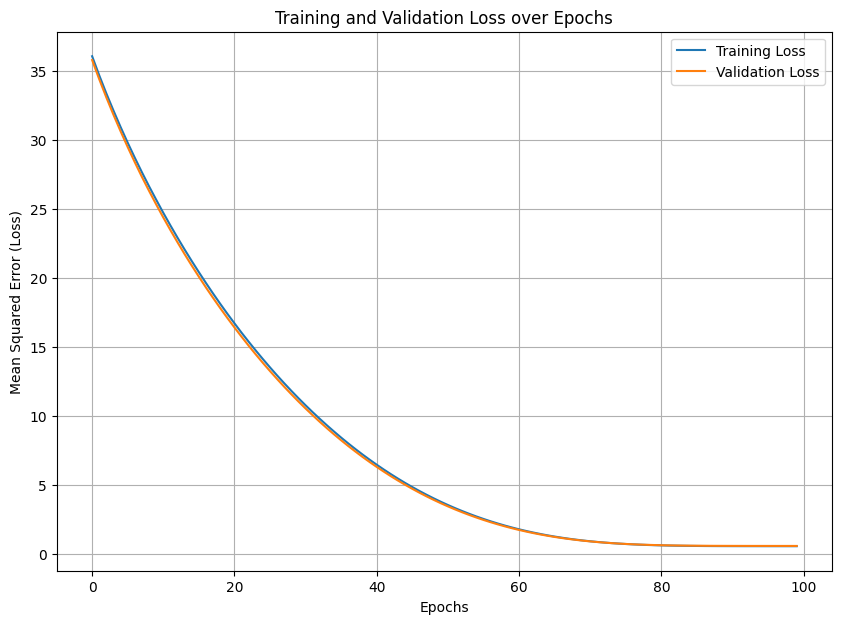

In [ ]:
# Plot 2: Loss (y axis) vs epochs (x axis) for training
plt.figure(figsize=(10, 7))
plt.plot(history.history['loss'], label='Training Loss')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()